# 04 — Warm-Start Fine-Tune

Before generating synthetic data at scale, we give the model a head start.

This notebook fine-tunes the base model on all knowledge pairs accumulated by
notebooks 03, 05, 06, 07, and 07b. After training, the model already understands
ARO syntax, knows the action vocabulary, and can produce valid programs — which
means notebook 08's RL explore loop starts with a much higher success rate instead
of failing constantly and learning nothing.

**Why LoRA?** It adapts the model with a tiny fraction of the parameters (rank 16,
16 layers), which fits in Apple Silicon unified memory and trains in minutes rather
than days. The adapter is saved and automatically loaded by every subsequent notebook.

**Run timing:** You can run notebook 04 as soon as notebook 03 finishes for a quick
warm-start. For best results, run it again after all of 05, 06, 07, and 07b have
appended their pairs — the more pairs the adapter sees, the better notebook 08 performs.

**Input:**  `../data/02_knowledge/knowledge_pairs.jsonl`
            `../data/02_knowledge/knowledge.json` (for system prompt)
**Output:** `../data/adapters/warm_start/` (LoRA adapter)
            `../data/02_knowledge/knowledge.json` (updated with adapter path)

In [1]:
import sys, importlib
from pathlib import Path
_cfg_dir = Path('.').resolve()
if _cfg_dir not in [Path(p) for p in sys.path]:
    sys.path.insert(0, str(_cfg_dir))
import config; importlib.reload(config); from config import *
print(f'Config loaded | model={MODEL_ID}')
print(f'ARO root:  {ARO_ROOT}')
print(f'Pairs:     {PAIRS_FILE}')
print(f'Adapters:  {ADAPTER_DIR}')

import gc, json, re, random, subprocess, sys
from pathlib import Path
from collections import Counter

with open(DATA_DIR / 'knowledge.json') as f:
    kb = json.load(f)

print(f'Knowledge pairs: {PAIRS_FILE}')
print(f'Adapter output:  {ADAPTER_DIR}')

TRAIN_ON_BASE=True → using base model: mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
TRAIN_ON_BASE=True → using base model: mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
Config loaded | model=mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
ARO root:  /Users/kris/Projects/ARO/ARO-Train
Pairs:     /Users/kris/Projects/ARO/ARO-Train/Train/data/02_knowledge/knowledge_pairs.jsonl
Adapters:  /Users/kris/Projects/ARO/ARO-Train/Train/data/adapters
Knowledge pairs: /Users/kris/Projects/ARO/ARO-Train/Train/data/02_knowledge/knowledge_pairs.jsonl
Adapter output:  /Users/kris/Projects/ARO/ARO-Train/Train/data/adapters


In [2]:
# Load all knowledge pairs produced by notebooks 03 and 05
all_pairs = []
with open(PAIRS_FILE) as f:
    for line in f:
        if line.strip():
            try:
                all_pairs.append(json.loads(line))
            except Exception:
                pass

sources = Counter(p.get('source', '').split(':')[0] for p in all_pairs)
scores  = Counter(round(p.get('score', 1.0), 1) for p in all_pairs)

print(f'Total pairs: {len(all_pairs)}')
print('\nBy source:')
for src, n in sorted(sources.items(), key=lambda x: -x[1]):
    print(f'  {src:30s}: {n}')
print('\nBy score:')
for score, n in sorted(scores.items(), key=lambda x: -x[0]):
    print(f'  {score}: {n}')

Total pairs: 4381

By source:
  proposal                      : 617
  example                       : 335
  book                          : 231
                                : 141
  actions_context               : 84
  aro/Book/Book/TheLanguageGuide/Chapter47-TerminalUI.md@0f958770aa: 58
  actions_usage                 : 58
  actions_explain               : 58
  actions_which                 : 58
  actions_context_static        : 58
  aro/Book/Book/TheEssentialPrimer/TheEssentialPrimer.md@fb6985460e: 36
  aro/Book/Book/TheLanguageGuide/Chapter16-HandlerGuards.md@0f958770aa: 32
  aro_by_example                : 28
  aro/Book/Book/TheLanguageGuide/Chapter11-Immutability.md@0f958770aa: 26
  aro/Book/Book/TheLanguageGuide/Chapter13-EventBus.md@0f958770aa: 26
  aro/Book/Book/TheLanguageGuide/Chapter26-Plugins.md@0f958770aa: 26
  aro/Book/Book/TheLanguageGuide/Chapter44-Templates.md@0f958770aa: 26
  aro/Book/Book/AROByExample/AppendixA-CompleteCode.md@fb6985460e: 24
  aro/Book/Book/TheLang

In [3]:
# Build system prompt from action metadata (same prompt used in notebooks 03 and 06)
action_lines = []
for a in kb['actions']:
    if a['verbs']:
        v = '/'.join(a['verbs'][:3])
        p = ', '.join(a['prepositions'][:4])
        action_lines.append(f'- {v}  (role: {a["role"]}, prepositions: {p})')

SYSTEM_PROMPT = f"""You are an expert ARO language programmer.
ARO (Action Result Object) is a DSL for business logic as natural-language statements.

SYNTAX:
  (FeatureSetName: BusinessActivity) {{
      Verb [the] <result[:qualifier]> preposition [the] <object[:qualifier]>.
  }}

KEY RULES:
- Articles (a/an/the) are optional
- String concatenation: ++ (NOT +)
- Variable names: hyphenated lowercase e.g. <user-id>, <order-total>
- Forbidden variable name prefixes: is-, with-, empty-
- Exactly ONE Application-Start per application
- openapi.yaml required for HTTP server; operationId must match feature set name
- Long-running apps: Keepalive the <application> for the <events>.
- Return statuses: <OK: status>, <Created: status>, <NotFound: status>
- HTTP path params: Extract the <id> from the <pathParameters: id>.
- Request body:     Extract the <data> from the <request: body>.

AVAILABLE ACTIONS:
{chr(10).join(action_lines[:40])}

Always wrap ARO code in ```aro ... ``` fences."""

print(f'System prompt: {len(SYSTEM_PROMPT)} chars')

System prompt: 3105 chars


## Warm-Start Fine-Tune

Fine-tune Qwen2.5-Coder on all extracted pairs so it understands ARO syntax
before notebook 06 starts generating synthetic data.

Uses 16 LoRA layers with a conservative learning rate of 1e-5.
Training runs for **2 full epochs** so the model sees every training pair at least
twice. Validation loss is measured every 50 iterations for early-stopping visibility.
Batch size 4 (with grad-checkpoint) smooths gradient noise compared to batch 2.

Sequences are truncated to 2048 tokens.

The adapter is saved to `../data/adapters/warm_start/` and notebook 06
will automatically load it as the starting point for RL fine-tuning rounds.

TRAIN_ON_BASE=True → using base model: mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
Config loaded | model=mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
ARO root:  /Users/kris/Projects/ARO/ARO-Train
Pairs:     /Users/kris/Projects/ARO/ARO-Train/Train/data/02_knowledge/knowledge_pairs.jsonl
Adapters:  /Users/kris/Projects/ARO/ARO-Train/Train/data/adapters
Tokenizer loaded: mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit
Pairs after expansion: 4375  (kept 4224, split into 151, dropped 89)
After dedup: 3022 (removed 1353 duplicates)
SFT data: 2569 train, 453 valid
Warm-start: 1284 iters (~2.0 epochs), batch_size=4, 16 LoRA layers
Val every 50 iters, save every 256 iters


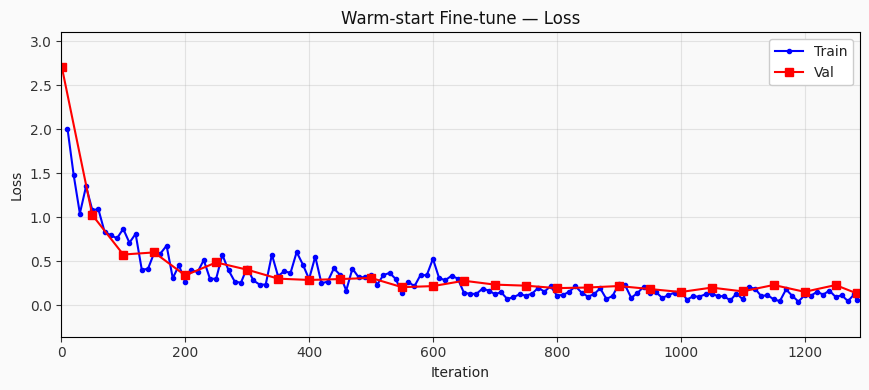

Fine-tuning:   0%|          | 0/1284 [00:00<?, ?iter/s]

Running: /Users/kris/Projects/ARO/ARO-Train/Train/.venv/bin/python -m mlx_lm lora --model mlx-community/Qwen3-Coder-30B-A3B-Instruct-4bit --data /Users/kris/Projects/ARO/ARO-Train/Train/data/warm_start_sft --train --num-layers 16 --iters 1284 --batch-size 4 --learning-rate 1e-5 --adapter-path /Users/kris/Projects/ARO/ARO-Train/Train/data/adapters/warm_start --mask-prompt --max-seq-length 2048 --grad-checkpoint --save-every 256 --steps-per-eval 50 --val-batches 25


Fine-tuning:   0%|          | 0/1284 [00:00<?, ?iter/s]

  Loading pretrained model
  Fetching 15 files: 100%|██████████| 15/15 [00:00<00:00, 16165.10it/s]


Fine-tuning:   0%|          | 0/1284 [00:02<?, ?iter/s]

...

  iter 1284/1284  │  train_loss 0.0660  │  lr 1.00e-05  │  0.595 it/s  │  135 tok/s  │  991038 tokens  │  mem 32.274 GB  │  ETA 0m00s


Fine-tuning: 100%|██████████| 1284/1284 [2:06:45<00:00,  6.57s/iter, loss=0.066, it/s=0.595, mem_GB=32.274, ETA=0m00s]

  Saved final weights to /Users/kris/Projects/ARO/ARO-Train/Train/data/adapters/warm_start/adapters.safetensors.


Fine-tuning: 100%|██████████| 1284/1284 [2:06:46<00:00,  5.92s/iter, loss=0.066, it/s=0.595, mem_GB=32.274, ETA=0m00s]



Warm-start adapter saved to: /Users/kris/Projects/ARO/ARO-Train/Train/data/adapters/warm_start


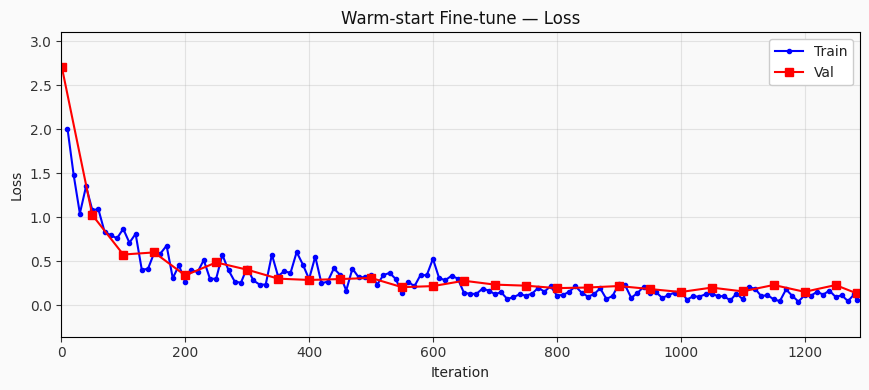

In [4]:
import sys, importlib
from pathlib import Path
_cfg_dir = Path('.').resolve()
if _cfg_dir not in [Path(p) for p in sys.path]:
    sys.path.insert(0, str(_cfg_dir))
import config; importlib.reload(config); from config import *
print(f'Config loaded | model={MODEL_ID}')
print(f'ARO root:  {ARO_ROOT}')
print(f'Pairs:     {PAIRS_FILE}')
print(f'Adapters:  {ADAPTER_DIR}')

import os, warnings
os.environ.setdefault('TRANSFORMERS_NO_ADVISORY_WARNINGS', '1')
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')
warnings.filterwarnings('ignore', message='.*IProgress not found.*')
warnings.filterwarnings('ignore', message='.*None of PyTorch.*')

import matplotlib.pyplot as plt
from IPython import display as ipydisplay
try:
    import ipywidgets
    from tqdm.notebook import tqdm as _tqdm_nb
    tqdm = _tqdm_nb
except Exception:
    from tqdm import tqdm

SFT_DIR = DATA_ROOT / 'warm_start_sft'
SFT_DIR.mkdir(parents=True, exist_ok=True)

import transformers
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    _tok = transformers.AutoTokenizer.from_pretrained(MODEL_ID)
print(f'Tokenizer loaded: {MODEL_ID}')

MAX_TOKENS = 2000   # leave margin below 2048 hard limit

def _count_tokens(instruction, output):
    text = _tok.apply_chat_template([
        {'role': 'system',    'content': SYSTEM_PROMPT},
        {'role': 'user',      'content': instruction},
        {'role': 'assistant', 'content': output},
    ], tokenize=False, add_generation_prompt=False)
    return len(_tok.encode(text))

# ── Pre-process: split long pairs, keeping openapi.yaml with EVERY split ─────
_file_section_re = re.compile(r'(##\s+\S+.*?)(?=\n##\s+\S+|\Z)', re.DOTALL)
_openapi_re      = re.compile(r'##\s+openapi\.yaml.*?(?=\n##\s+\S+|\Z)', re.DOTALL)

def _split_by_file(output):
    sections = _file_section_re.findall(output)
    return sections if len(sections) > 1 else []

def _pair_fields(p):
    """Extract (instruction, output) from flat or messages format."""
    if 'instruction' in p:
        return p['instruction'], p.get('output', '')
    msgs = p.get('messages', [])
    user = next((m['content'] for m in msgs if m.get('role') == 'user'), '')
    asst = next((m['content'] for m in msgs if m.get('role') == 'assistant'), '')
    return user, asst

def expand_pair(p):
    instruction, output = _pair_fields(p)

    if _count_tokens(instruction, output) <= MAX_TOKENS:
        return [(instruction, output)]

    sections = _split_by_file(output)
    if sections:
        openapi_section = ''
        openapi_m = _openapi_re.search(output)
        if openapi_m:
            openapi_section = openapi_m.group(0).strip() + '\n\n'

        result = []
        for s in sections:
            if 'openapi.yaml' in s:
                continue
            combined = (openapi_section + s).strip() if openapi_section else s
            combined_instr = instruction + (' (see openapi.yaml above for contract)' if openapi_section else '')
            if _count_tokens(combined_instr, combined) <= MAX_TOKENS:
                result.append((combined_instr, combined))
            elif _count_tokens(instruction, s) <= MAX_TOKENS:
                result.append((instruction, s))
        if result:
            return result

    return []   # drop

expanded, stats = [], {'kept': 0, 'split': 0, 'dropped': 0}
for p in all_pairs:
    parts = expand_pair(p)
    if not parts:
        stats['dropped'] += 1
    elif len(parts) == 1 and parts[0][1] == _pair_fields(p)[1]:
        stats['kept'] += 1
        expanded.append({**p, 'instruction': parts[0][0], 'output': parts[0][1]})
    else:
        stats['split'] += len(parts)
        for instruction, output in parts:
            expanded.append({'instruction': instruction, 'output': output,
                             'source': p.get('source', ''), 'score': p.get('score', 1.0)})

print(f'Pairs after expansion: {len(expanded)}  '
      f'(kept {stats["kept"]}, split into {stats["split"]}, dropped {stats["dropped"]})')

# ── Deduplicate by instruction prefix ────────────────────────────────────────
seen_instr, deduped = set(), []
for p in expanded:
    key = p['instruction'][:120]
    if key not in seen_instr:
        seen_instr.add(key)
        deduped.append(p)
print(f'After dedup: {len(deduped)} (removed {len(expanded) - len(deduped)} duplicates)')
expanded = deduped

# ── Shuffle and split: 85% train, 15% valid ──────────────────────────────────
import random
plt.style.use('default')
plt.rcParams.update({
    'text.color': '#222222',
    'axes.labelcolor': '#222222',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.titlecolor': '#111111',
    'legend.edgecolor': '#cccccc',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0,
    'figure.facecolor': '#fafafa',
    'axes.facecolor': '#f9f9f9',
})

random.shuffle(expanded)
split = max(4, int(len(expanded) * 0.15))

def pair_to_chat(p):
    return {'messages': [
        {'role': 'system',    'content': SYSTEM_PROMPT},
        {'role': 'user',      'content': p['instruction']},
        {'role': 'assistant', 'content': p['output']},
    ]}

(SFT_DIR / 'valid.jsonl').write_text(
    '\n'.join(json.dumps(pair_to_chat(p)) for p in expanded[:split]))
(SFT_DIR / 'train.jsonl').write_text(
    '\n'.join(json.dumps(pair_to_chat(p)) for p in expanded[split:]))

n_train = len(expanded) - split

# ── Training parameters ─────────────────────────────────────────────────────
batch_size = 4
epoch_iters = n_train // batch_size
iters = max(200, min(2000, epoch_iters * 2))   # ~2 full epochs, capped at 2000
val_every = 50                                   # measure val loss every 50 iters
save_every = max(100, iters // 5)                # save checkpoints ~5 times

print(f'SFT data: {n_train} train, {split} valid')
print(f'Warm-start: {iters} iters (~{iters * batch_size / n_train:.1f} epochs), '
      f'batch_size={batch_size}, 16 LoRA layers')
print(f'Val every {val_every} iters, save every {save_every} iters')

cmd = [
    sys.executable, '-m', 'mlx_lm', 'lora',
    '--model',          MODEL_ID,
    '--data',           str(SFT_DIR),
    '--train',
    '--num-layers',     '16',
    '--iters',          str(iters),
    '--batch-size',     str(batch_size),
    '--learning-rate',  '1e-5',
    '--adapter-path',   str(WARM_ADAPTER),
    '--mask-prompt',
    '--max-seq-length', '2048',
    '--grad-checkpoint',
    '--save-every',     str(save_every),
    '--steps-per-eval', str(val_every),
    '--val-batches',    '25',
]

# ── Live loss graph ───────────────────────────────────────────────────────────
train_iters, train_losses = [], []
val_iters,   val_losses   = [], []

fig, ax = plt.subplots(figsize=(9, 4))
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss')
ax.set_title('Warm-start Fine-tune — Loss')
ax.grid(True, alpha=0.3)
train_line, = ax.plot([], [], 'b-o', ms=3, lw=1.5, label='Train')
val_line,   = ax.plot([], [], 'r-s', ms=6, lw=1.5, label='Val')
ax.legend()
plt.tight_layout()

_fig_handle = ipydisplay.display(fig, display_id=True)

def _refresh_plot():
    if train_losses:
        train_line.set_data(train_iters, train_losses)
    if val_losses:
        val_line.set_data(val_iters, val_losses)
    all_y = train_losses + val_losses
    if all_y:
        lo, hi = min(all_y), max(all_y)
        pad = max(0.05, (hi - lo) * 0.15)
        ax.set_ylim(lo - pad, hi + pad)
    all_x = train_iters + val_iters
    if all_x:
        ax.set_xlim(0, max(iters, max(all_x)) + 5)
    fig.canvas.draw()
    _fig_handle.update(fig)

_train_re = re.compile(
    r'Iter\s+(\d+):\s+Train loss\s+([\d.]+)'
    r'(?:.*?Learning Rate\s+([\d.e+-]+))?'
    r'(?:.*?It/sec\s+([\d.]+))?'
    r'(?:.*?Tokens/sec\s+([\d.]+))?'
    r'(?:.*?Trained Tokens\s+([\d,]+))?'
    r'(?:.*?Peak mem\s+([\d.]+)\s*GB)?'
)
_val_re   = re.compile(r'Iter\s+(\d+):\s+Val loss\s+([\d.]+)(?:.*?Val took\s+([\d.]+)s)?')
_saved_re = re.compile(r'Adapter saved', re.IGNORECASE)

pbar      = tqdm(total=iters, desc='Fine-tuning', unit='iter', dynamic_ncols=True)
last_iter = 0

print('Running:', ' '.join(cmd))
proc = subprocess.Popen(
    cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    text=True, bufsize=1,
)
try:
    for raw_line in proc.stdout:
        line = raw_line.rstrip()

        m_train = _train_re.search(line)
        m_val   = _val_re.search(line)

        if m_train:
            it, loss    = int(m_train.group(1)), float(m_train.group(2))
            lr, it_sec  = m_train.group(3), m_train.group(4)
            tok_sec     = m_train.group(5)
            trained_tok = m_train.group(6)
            peak_mem    = m_train.group(7)

            train_iters.append(it)
            train_losses.append(loss)
            pbar.update(it - last_iter)
            last_iter = it

            eta_str = ''
            if it_sec:
                eta_s = (iters - it) / float(it_sec)
                h, r  = divmod(int(eta_s), 3600)
                m_, s = divmod(r, 60)
                eta_str = f'{h}h{m_:02d}m' if h else f'{m_}m{s:02d}s'

            postfix = {'loss': f'{loss:.3f}'}
            if it_sec:   postfix['it/s']   = it_sec
            if peak_mem: postfix['mem_GB'] = peak_mem
            if eta_str:  postfix['ETA']    = eta_str
            pbar.set_postfix(postfix)

            parts = [f'iter {it:>4}/{iters}', f'train_loss {loss:.4f}']
            if lr:          parts.append(f'lr {float(lr):.2e}')
            if it_sec:      parts.append(f'{float(it_sec):.3f} it/s')
            if tok_sec:     parts.append(f'{float(tok_sec):.0f} tok/s')
            if trained_tok: parts.append(f'{trained_tok.replace(",","")} tokens')
            if peak_mem:    parts.append(f'mem {peak_mem} GB')
            if eta_str:     parts.append(f'ETA {eta_str}')
            tqdm.write('  ' + '  │  '.join(parts))
            _refresh_plot()

        elif m_val:
            it, loss = int(m_val.group(1)), float(m_val.group(2))
            val_took = m_val.group(3)

            val_iters.append(it)
            val_losses.append(loss)
            pbar.set_postfix({'loss': f'{train_losses[-1]:.3f}' if train_losses else '?',
                              'val':  f'{loss:.3f}'})
            took_str = f'  ({val_took}s)' if val_took else ''
            tqdm.write(f'  ── val ──  iter {it:>4}/{iters}  val_loss {loss:.4f}{took_str}')
            _refresh_plot()

        elif _saved_re.search(line):
            tqdm.write(f'  ✓ {line}')
        elif line.strip():
            tqdm.write(f'  {line}')

finally:
    proc.wait()
    pbar.close()

_refresh_plot()

if proc.returncode == 0:
    print(f'\nWarm-start adapter saved to: {WARM_ADAPTER}')
else:
    print(f'\nFine-tune exited with code {proc.returncode}')

## Best-Checkpoint Selection + CSV Export

The warm-start curve often overfits: val loss bottoms mid-training then climbs.
Instead of blindly using the final adapter, we find the checkpoint closest to the
best val loss and promote it as the active adapter. This prevents shipping an
over-trained adapter that hallucinates downstream.

In [5]:
import csv, shutil
from datetime import date as _date

_run_dir = Path('.') / 'run' / _date.today().isoformat()
_run_dir.mkdir(parents=True, exist_ok=True)

# ── 1. Best-checkpoint selection ─────────────────────────────────────────────
# mlx_lm saves checkpoints as NNNNNNN_adapters.safetensors in the adapter dir.
# We find the one closest to the best val_loss iteration and promote it.

best_val_iter = None
best_val_loss = float('inf')
if val_iters and val_losses:
    for it, vl in zip(val_iters, val_losses):
        if vl < best_val_loss:
            best_val_loss = vl
            best_val_iter = it
    print(f'Best val loss: {best_val_loss:.4f} at iter {best_val_iter}')

    # Find available checkpoints
    ckpts = sorted(WARM_ADAPTER.glob('*_adapters.safetensors'))
    if ckpts:
        # Parse iteration number from filename (e.g. 0000200_adapters.safetensors)
        def _ckpt_iter(p):
            try: return int(p.stem.split('_')[0])
            except: return 0

        ckpt_iters = [(p, _ckpt_iter(p)) for p in ckpts]
        # Find checkpoint closest to (but not after) best_val_iter
        best_ckpt = min(ckpt_iters, key=lambda x: abs(x[1] - best_val_iter))
        best_ckpt_path, best_ckpt_it = best_ckpt

        final_adapter = WARM_ADAPTER / 'adapters.safetensors'
        if best_ckpt_it != iters and final_adapter.exists():
            # The final adapter is NOT the best — replace it
            print(f'Final adapter is iter {iters}, but best val was iter {best_val_iter}')
            print(f'Promoting checkpoint iter {best_ckpt_it}: {best_ckpt_path.name}')
            backup = WARM_ADAPTER / 'adapters_final_backup.safetensors'
            shutil.copy2(final_adapter, backup)
            shutil.copy2(best_ckpt_path, final_adapter)
            print(f'Replaced adapters.safetensors with iter-{best_ckpt_it} checkpoint')
            print(f'(Final adapter backed up to {backup.name})')
        else:
            print(f'Final adapter IS the best checkpoint (iter {best_ckpt_it}) — no change needed')
    else:
        print('No intermediate checkpoints found (save_every may be > iters)')
else:
    print('No validation data recorded — using final adapter as-is')

# ── 2. CSV export ────────────────────────────────────────────────────────────
csv_path = _run_dir / '04_warmstart_finetune.csv'
with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['iteration', 'train_loss', 'val_loss', 'selected_as_best'])

    # Build a lookup for val losses by iteration
    val_lookup = dict(zip(val_iters, val_losses))

    all_iters = sorted(set(train_iters) | set(val_iters))
    train_lookup = dict(zip(train_iters, train_losses))

    for it in all_iters:
        tl = f'{train_lookup[it]:.4f}' if it in train_lookup else ''
        vl = f'{val_lookup[it]:.4f}' if it in val_lookup else ''
        is_best = 'yes' if it == best_val_iter else ''
        writer.writerow([it, tl, vl, is_best])

print(f'\nCSV saved: {csv_path} ({len(all_iters)} rows)')

Best val loss: 0.1380 at iter 1284
Final adapter is iter 1284, but best val was iter 1284
Promoting checkpoint iter 1280: 0001280_adapters.safetensors
Replaced adapters.safetensors with iter-1280 checkpoint
(Final adapter backed up to adapters_final_backup.safetensors)

CSV saved: run/2026-04-27/04_warmstart_finetune.csv (130 rows)


In [6]:
# Update knowledge.json so notebook 06 finds the warm-start adapter automatically
kb['warm_start_adapter']    = str(WARM_ADAPTER)
kb['knowledge_pairs_file']  = str(PAIRS_FILE)
kb['knowledge_pairs_count'] = len(all_pairs)

with open(DATA_DIR / 'knowledge.json', 'w') as f:
    json.dump(kb, f, indent=2)

print('Updated knowledge.json')
print()
print('Next steps:')
print(f'  Adapter path: {WARM_ADAPTER}')
print(f'  Run notebook 06 — it will auto-load this adapter and run the RL explore loop')

Updated knowledge.json

Next steps:
  Adapter path: /Users/kris/Projects/ARO/ARO-Train/Train/data/adapters/warm_start
  Run notebook 06 — it will auto-load this adapter and run the RL explore loop


In [7]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
plt.style.use('default')
plt.rcParams.update({
    'text.color': '#222222',
    'axes.labelcolor': '#222222',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.titlecolor': '#111111',
    'legend.edgecolor': '#cccccc',
    'legend.facecolor': 'white',
    'legend.framealpha': 1.0,
    'figure.facecolor': '#fafafa',
    'axes.facecolor': '#f9f9f9',
    'savefig.facecolor': '#fafafa',
    'savefig.bbox': 'tight',
    'savefig.dpi': 150,
})
from pathlib import Path
from datetime import date as _date

_run_dir = Path('.') / 'run' / _date.today().isoformat()
_run_dir.mkdir(parents=True, exist_ok=True)
_out = _run_dir / '04_warmstart_finetune.png'

if train_losses:
    epochs_trained = iters * batch_size / n_train

    fig2, ax2 = plt.subplots(figsize=(10, 5))
    ax2.plot(train_iters, train_losses, 'b-o', ms=3, lw=1.5, label='Train loss')
    if val_losses:
        ax2.plot(val_iters, val_losses, 'r-s', ms=7, lw=1.5, label='Val loss')
        ax2.axhline(best_val_loss, color='r', lw=0.8, ls='--', alpha=0.5,
                    label=f'Best val {best_val_loss:.4f}')
        ax2.plot(best_val_iter, best_val_loss, marker='*', color='gold',
                 ms=20, zorder=10, markeredgecolor='black', markeredgewidth=0.5,
                 label=f'Best ckpt (iter {best_val_iter})')
        if best_val_iter and best_val_iter < iters:
            ax2.axvspan(best_val_iter, iters, alpha=0.08, color='red',
                        label='Overfit region')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Loss')
    ax2.set_title(
        f'Warm-Start Fine-Tune \u2014 {n_train} pairs  \u00b7  {iters} iters ({epochs_trained:.1f} epochs)'
        f'  \u00b7  batch {batch_size}  \u00b7  rank 16 / 16 layers',
        fontsize=12, fontweight='bold'
    )
    ax2.legend(fontsize=9, loc='upper right')
    ax2.grid(alpha=0.3)
    fig2.tight_layout()
    fig2.savefig(_out)
    plt.close(fig2)
    print(f'Saved: {_out}')
else:
    print('No training data to plot \u2014 run the fine-tune cell first.')

Saved: run/2026-04-27/04_warmstart_finetune.png
